In [1]:
pip install pandas numpy matplotlib shap scikit-learn xgboost lightgbm pymongo python-dotenv gridfs

ERROR: Could not find a version that satisfies the requirement gridfs (from versions: none)
ERROR: No matching distribution found for gridfs


In [3]:
!pip install pymongo


  Using cached pymongo-4.16.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (10.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 24.4 MB/s eta 0:00:00


In [1]:
"""
SHAP Analysis of AQI Prediction Model from MongoDB (GridFS)

• Selects BEST model based on highest R²
• Uses exact training feature list
• Displays Feature Importance Table first
• Shows each SHAP plot separately
"""

import pickle
import pandas as pd
import numpy as np
from pymongo import MongoClient
from gridfs import GridFS
import shap
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv

# =========================
# MongoDB Setup
# =========================

load_dotenv()
MONGO_URI = os.getenv("MONGO_URI")
# Connect to MongoDB

client = MongoClient(MONGO_URI)
db = client["aqi_project"]



data_collection = db["engineered_data_final"]
model_registers = db["model_registers"]
fs = GridFS(db)

# =========================
# Load Engineered Data
# =========================
def load_data():
    cursor = data_collection.find({})
    df = pd.DataFrame(list(cursor))

    if df.empty:
        raise ValueError("No data found in engineered_data_final collection.")

    if "_id" in df.columns:
        df.drop(columns=["_id"], inplace=True)

    if "timestamp" in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"])
        df = df.sort_values("timestamp").reset_index(drop=True)

    return df


df = load_data()
print(f"Loaded {len(df)} rows")

# =========================
# Load BEST Model (Highest R²)
# =========================
best_model_doc = model_registers.find_one(
    {},
    sort=[("metrics.R2", -1)]
)

if not best_model_doc:
    raise ValueError("No models found in model_registers.")

print("\n==============================")
print(f"Best Model: {best_model_doc['model_name']}")
print(f"R² Score: {best_model_doc['metrics']['R2']}")
print("==============================\n")

gridfs_file_id = best_model_doc["gridfs_file_id"]
model_bytes = fs.get(gridfs_file_id).read()
model = pickle.loads(model_bytes)

# =========================
# Prepare Features (Exact Match)
# =========================
feature_cols = best_model_doc["features"]

X = df[feature_cols].replace([np.inf, -np.inf], np.nan)
X = X.ffill().bfill()

print(f"Using {len(feature_cols)} trained features")

# =========================
# Sample for SHAP
# =========================
sample_size = min(300, len(X))
X_sample = X.sample(sample_size, random_state=42)

# =========================
# SHAP Analysis
# =========================
print("\nRunning SHAP analysis...\n")

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# =====================================================
# 1️⃣ FEATURE IMPORTANCE TABLE (Mean Absolute SHAP)
# =====================================================
mean_abs_shap = np.abs(shap_values).mean(axis=0)

importance_df = pd.DataFrame({
    "Feature": X_sample.columns,
    "Mean_Absolute_SHAP": mean_abs_shap
}).sort_values(by="Mean_Absolute_SHAP", ascending=False)

print("\nTop 10 Most Important Features:\n")
print(importance_df.head(10))




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\PMLS\.conda\envs\aqi-env\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\PMLS\.conda\envs\aqi-env\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\PMLS\.conda\envs\aqi-env\Lib\site-packages\ipykernel\kernelapp.py", line 758, in start
    self.io_loop.start()
  File "c:\Users\PM

AttributeError: _ARRAY_API not found

c:\Users\PMLS\.conda\envs\aqi-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 2204 rows

Best Model: Random Forest
R² Score: 0.7789

Using 29 trained features

Running SHAP analysis...


Top 10 Most Important Features:

             Feature  Mean_Absolute_SHAP
17         aqi_lag_1           10.085504
21   aqi_roll_mean_6            5.907694
5              ozone            5.075107
25     aqi_change_1h            5.065090
20        aqi_lag_24            4.825822
1              pm2_5            4.354993
0               pm10            4.062396
4    sulphur_dioxide            2.490688
23  aqi_roll_mean_24            2.370429
3   nitrogen_dioxide            2.015465


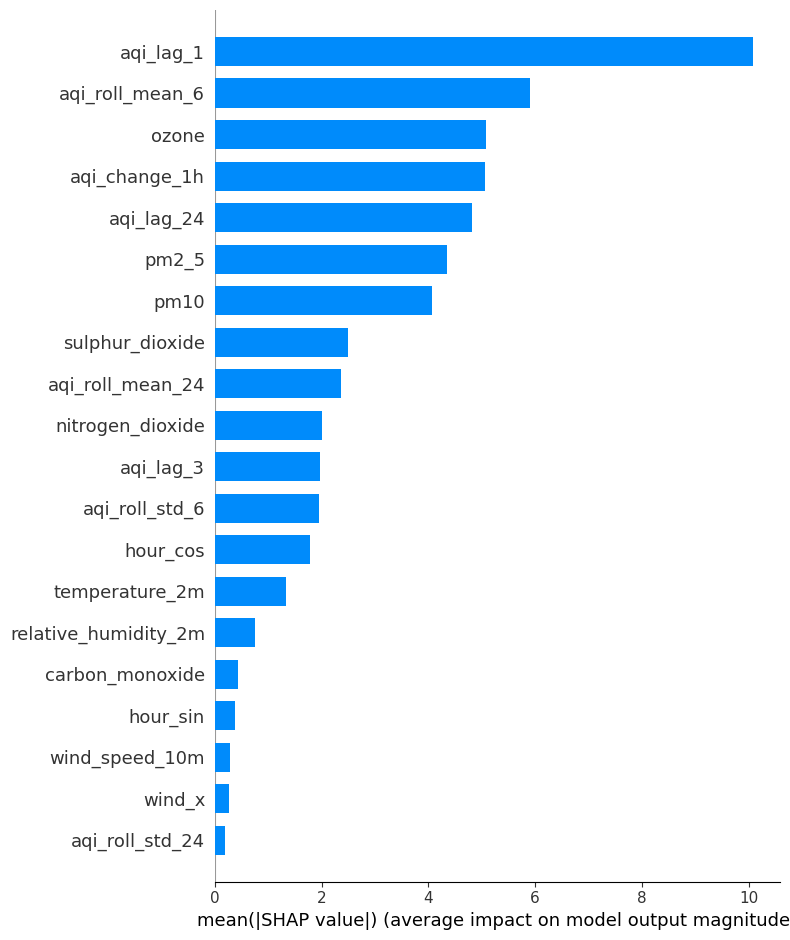

In [2]:
# =====================================================
# 2️⃣ GLOBAL BAR PLOT (Separate Figure)
# =====================================================
plt.figure(figsize=(12,6))
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=True)





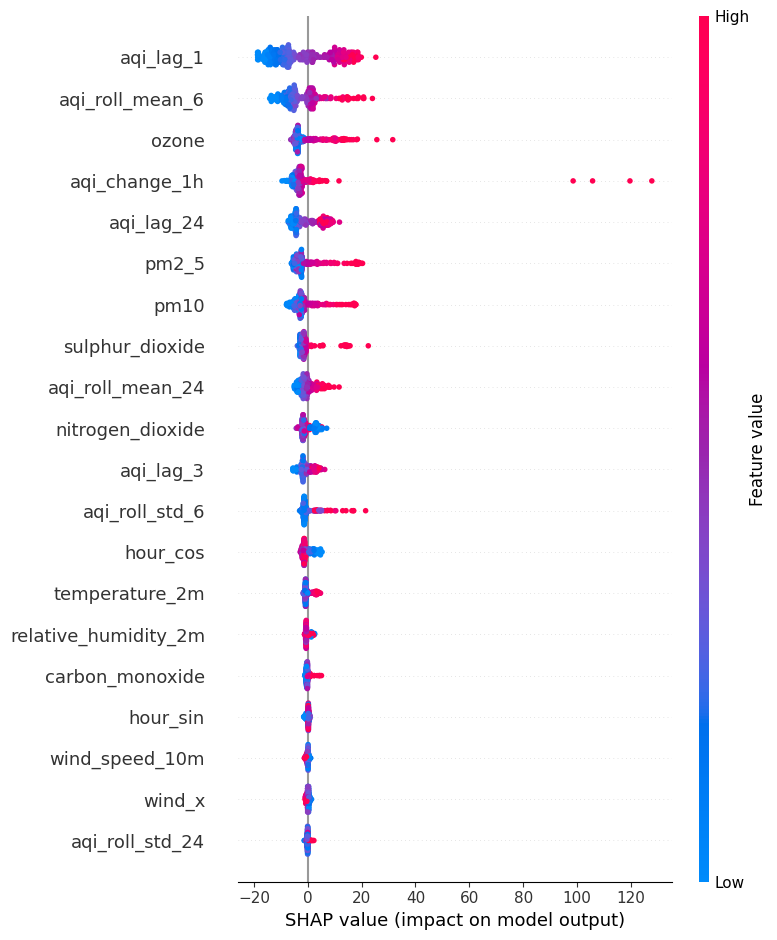

In [3]:
# =====================================================
# 3️⃣ BEESWARM PLOT (Separate Figure)
# =====================================================
plt.figure(figsize=(12,6))
shap.summary_plot(shap_values, X_sample, show=True)

<Figure size 1000x500 with 0 Axes>

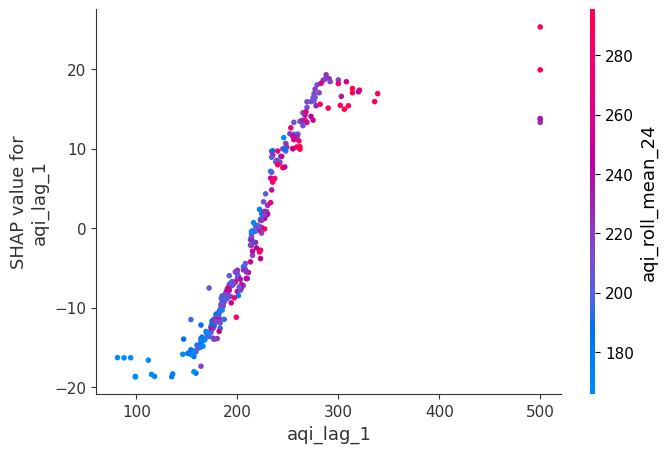

<Figure size 1000x500 with 0 Axes>

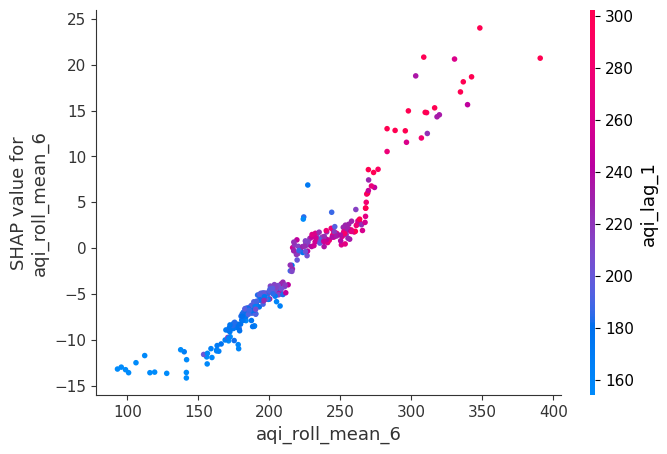

<Figure size 1000x500 with 0 Axes>

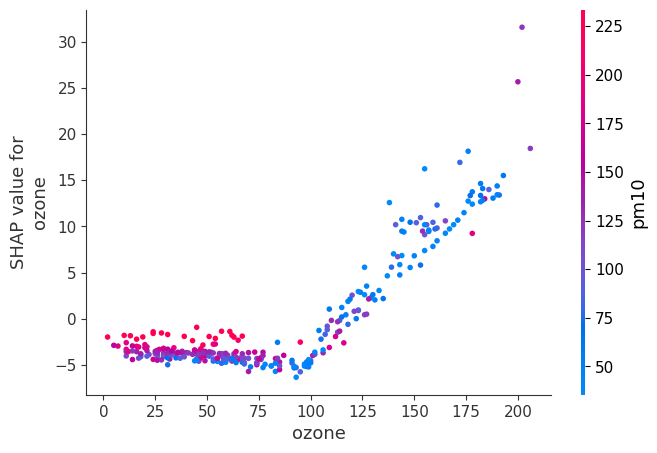


SHAP analysis complete!


In [4]:
# =====================================================
# 4️⃣ DEPENDENCE PLOTS (Separate Figures)
# =====================================================
top3_features = importance_df["Feature"].head(3)

for feature in top3_features:
    plt.figure(figsize=(10,5))
    shap.dependence_plot(feature, shap_values, X_sample)

print("\nSHAP analysis complete!")